# Simple linear regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Estimated coefficients: b_0 = 1.2363636363636363, b_1 =  1.1696969696969697


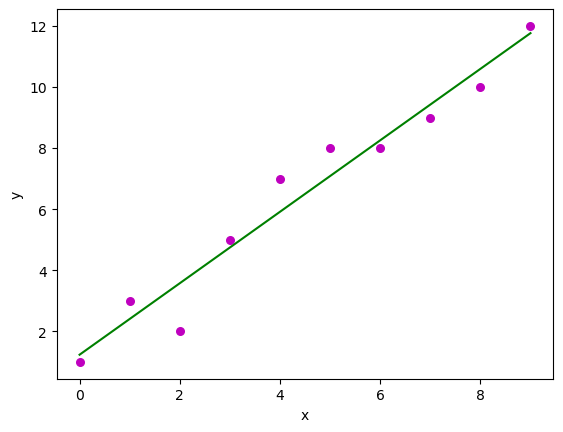

In [39]:
# esimating coefficient Function
def estimate_coef(x,y):
    """
    This function estimate_coef(), takes the input data x (independent variable) and
    y (dependent variable) and estimates the coefficients of the linear regression line using the least squares method. 
    """

    # no of observations
    n = np.size(x)

    # mean of x and y
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    ss_xy = np.sum(y*x) - n*m_y*m_x
    ss_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    b_1 = ss_xy / ss_xx
    b_0 = m_y - b_1*m_x

    return (b_0, b_1)

#  Plotting Regression Line Function
def plot_regression_line(x, y, b):
    """
    This function plot_regression_line(),takes the input data x (independent variable), y (dependent variable) 
    and the estimated coefficients b to plot the regression line and the data points.
    """
    # plotting the actual points as scatter plot
    plt.scatter(x, y, color = 'm', marker = 'o', s =30)

    # predicted response vector
    y_pred = b[0] + b[1]*x

    # plot the reg line
    plt.plot(x, y_pred,color = 'g')

    # putting labels 
    plt.xlabel('x')
    plt.ylabel('y')

    # show plot
    plt.show()

# main fuction
def main():
    # observations / data
    x = np.arange(0,10)
    y = np.array([1,3,2,5,7,8,8,9,10,12])

    # estimating coefficients
    b = estimate_coef(x, y)
    
    # printing the estimated coefficients
    print(f"Estimated coefficients: b_0 = {b[0]}, b_1 =  {b[1]}")

    # plotting the regression line
    plot_regression_line(x,y,b)

# running the main function 
if __name__ ==  '__main__':
    main()

Estimated coefficients: b_0 = 1.2363636363636363, b_1 =  1.1696969696969697


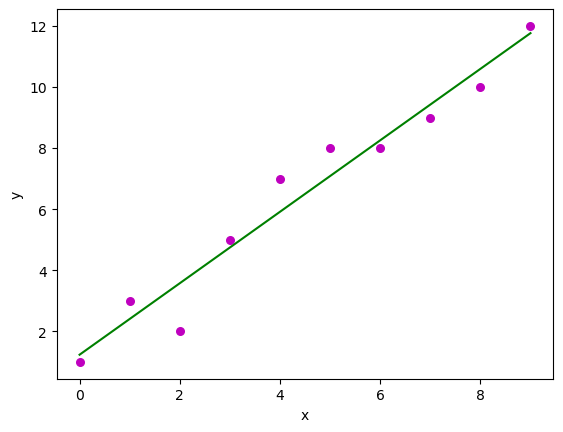

None


In [57]:
print(main())

In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Step 2: Load and Explore the Dataset

In [8]:
cali = fetch_california_housing()
cali.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

# cali.DESCR: california_housing_dataset:

**Data Set Characteristics:**

Number of Instances: 20640

Number of Attributes: 8 numeric, predictive attributes and the target

Attribute Information:

- MedInc:    median income in block group
- HouseAge:  median house age in block group
- AveRooms:  average number of rooms per household
- AveBedrms:  average number of bedrooms per household
- Population:  block group population
- AveOccup:   average number of household members
- Latitude:  block group latitude
- Longitude:  block group longitude

Missing Attribute Values: None 

This dataset was obtained from the StatLib repository 

https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts, expressed in hundreds of thousands of dollars ($100,000.).

This dataset was derived from the 1990 U.S. census, using one row per census block group. 

A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data. A block group typically has a population of 600 to 3,000 people.

A household is a group of people residing within a home. Since the average number of rooms and bedrooms in this dataset are provided per household, these columns may take surprisingly large values for block groups with few households and many empty houses, such as vacation resorts.

References: Pace, R. Kelley and Ronald Barry, Sparse Spatial Autoregressions, Statistics and Probability Letters, 33 (1997), 291-297

In [10]:
df = pd.DataFrame(cali.data, columns=cali.feature_names)
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


# Step 3: Selecting Features and Splitting the Data

In [13]:
# Define the feature (independent variable) and target (dependent variable)
X = df[['AveRooms']]  # Number of rooms
y = cali.target  # House prices

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (16512, 1)
Testing set size: (4128, 1)


# Step 4: Train the Simple Linear Regression Model

In [15]:
# Train the Simple Linear Regression Model
# create linear regression model
model = LinearRegression()

# train the model on training data
model.fit(X_train,y_train)

# print the intercept and coefficient
print(f"Intercept: {model.intercept_}, Coefficient: {model.coef_},")


Intercept: 1.6547622685968422, Coefficient: [0.07675559],


# Step 5: Make Predictions

In [17]:
# Predict house prices for the test set
y_pred = model.predict(X_test)

# Display the first few predictions alongside the actual values
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions.head())


    Actual  Predicted
0  0.47700   1.976537
1  0.45800   2.041563
2  5.00001   1.960031
3  2.18600   2.127856
4  2.78000   2.076380


# Step 6: Visualize the Regression Line

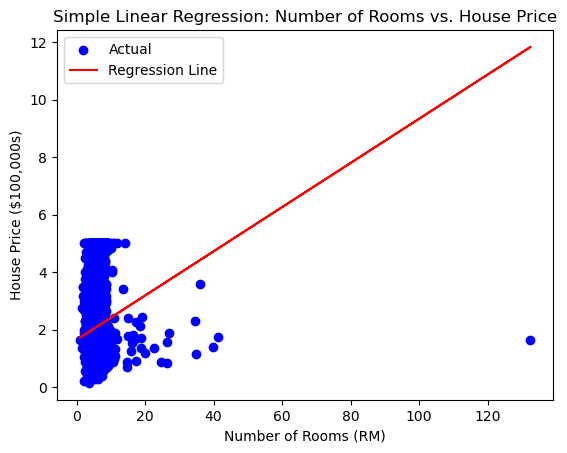

In [26]:
# Plot the actual data points
plt.scatter(X_test, y_test, color='blue', label='Actual')

# Plot the regression line
plt.plot(X_test, y_pred, color='red', label='Regression Line')

# Add labels and title
plt.xlabel('Number of Rooms (RM)')
plt.ylabel('House Price ($100,000s)')
plt.title('Simple Linear Regression: Number of Rooms vs. House Price')
plt.legend()
plt.show()


# Step 7: Evaluate the Model

In [28]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f"R-squared score: {r2}")

Mean Squared Error: 1.2923314440807299
R-squared score: 0.013795337532284901


# Univariate Linear Regression in Python

Univariate Linear Regression is a type of regression in which the target variable depends on only one independent variable. 

For univariate regression, we use univariate data. For instance, a dataset of points on a line can be considered as univariate data where abscissa can be considered as an input feature and ordinate can be considered as output/target. 

Y = 2x + 3,

x - feature,

y - target

The line of regression will be in the form of the following:

Y = b0 + b1 * X Where, b0 and b1 are the coefficients

## Utility Functions in Univariate Linear Regression Model
1. Prediction with linear regression

we redict the value of y on a given value of x by multiplying and adding the coefficient of regression to the x.

#Y = b0 + b1 * X

def predict(x, b0, b1):

    return b0 + b1 * x

2. Cost function

The cost function computes the error with the current value of regression coefficients. It quantitatively defines how far the model predicted value is from the actual value wrt regression coefficients which have the lowest rate of error. 

Mean-Squared Error(MSE) = sum of squares of difference between predicted and actual value

J(b1,b0)= 1/n * (yp−y)2

def cost(x, y, b0, b1):
    
    errors = []
    
    for x, y in zip(x, y):
    
        prediction = predict(x, b0, b1)
        
        expected = y
        
        difference = prediction-expected
        
        errors.append(difference)
    
    mse 
    
    = sum([error * error for error in errors])/len(errors)
    
    return mse

3. Gradient Descent For Parameter Estimation

We will use gradient descent for updating our regression coefficient. It is an optimization algorithm that we use to train our model. 

In gradient descent, we take the partial derivative of the cost function wrt to our regression coefficient and multiply with the learning rate alpha and subtract it from our coefficient to adjust our regression coefficient.

derivative of j,bo wrt bo and b1 

j'bo = 1/n * (yp - y)*2 

def grad_fun(x, y, b0, b1, i):
    
    return sum([
        
        2*(predict(xi, b0, b1)-yi)*1
        
        if i == 0
        
        else 2*(predict(xi, b0, b1)-yi)*xi
        
        for xi, yi in zip(x, y)
    
    ])/len(x)


4. Update Coefficients
At each iteration (epoch), the values of the regression coefficient are updated by a specific value wrt to the error from the previous iteration.

This updation is very crucial and is the crux of the machine learning applications that you write.

Updating the coefficients is done by penalizing their value with a fraction of the error that its previous values caused. 

This fraction is called the learning rate. This defines how fast our model reaches to point of convergence(the point where the error is ideally 0).

 
bi = bi – α ∗ ( ∂/∂b cost(x,y))
      
def update_coeff(x, y, b0, b1, i, alpha):
  
  bi -= alpha * cost_derivative(x, y, b0, b1, i)
  
  return bi

   
5. Stop Iterations

This is the function that is used to specify when the iterations should stop. As per the user, the algorithm stop_iteration generally returns true in the following conditions:

Max Iteration: Model is trained for a specified number of iterations.

Error value: Depending upon the value of the previous error, the algorithm decides whether to continue or stop.

Accuracy: Depending upon the last accuracy of the model, if it is larger than the mentioned accuracy, the algorithm returns True,

Hybrid: This is more often used. This combines more than one above mentioned conditions along with an exceptional break option. The exceptional break is a condition where training continues until when something bad happens. Something bad might include an overflow of results, time constraints exceeded, etc.   

In [31]:
class LinearRegressor:
    def __init__(self, x, y, alpha=0.01, b0=0, b1=0):
        """ 
        x: input feature
        y: result / target
        alpha: learning rate, default is 0.01
        b0, b1: linear regression coefficients.
        """
        self.i = 0
        self.x = x
        self.y = y
        self.alpha = alpha
        self.b0 = b0
        self.b1 = b1
        if len(x) != len(y):
            raise ValueError("x and y should have the same number of elements.")
    
    def cost_derivative(self):
        """Computes Mean Squared Error (MSE)."""
        errors = [(self.predict(xi) - yi) for xi, yi in zip(self.x, self.y)]
        mse = sum([error ** 2 for error in errors]) / len(errors)
        return mse

    def predict(self, x):
        """Predicts the value based on current regression coefficients."""
        return self.b0 + self.b1 * x

    def grad_fun(self, i):
        """Computes gradients for coefficients."""
        return sum([
            2 * (self.predict(xi) - yi) * (1 if i == 0 else xi)
            for xi, yi in zip(self.x, self.y)
        ]) / len(self.x)

    def update_coeff(self):
        """Updates coefficients using gradient descent."""
        self.b0 -= self.alpha * self.grad_fun(0)
        self.b1 -= self.alpha * self.grad_fun(1)

    def stop_iteration(self, max_epochs=1000):
        """Checks stopping condition."""
        self.i += 1
        return self.i >= max_epochs

    def fit(self):
        """Fits the model using gradient descent."""
        self.i = 0
        while not self.stop_iteration():
            self.update_coeff()



In [33]:
# Testing the corrected class
linearRegressor = LinearRegressor(
    x=[i for i in range(12)],
    y=[2 * i + 3 for i in range(12)],
    alpha=0.01
)

linearRegressor.fit()
print(linearRegressor.predict(12))  # Expected output: Around 27 (since y = 2x + 3)


27.005371609430334
